Based on: https://github.com/icepack/icepack2/commits/75b5b1413af3ad7d584424f9b4e64ad0bc57988f/notebooks/mismipp-dual-1d.ipynb

In [33]:
"""
Initial imports and function declarations
"""

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)

import ufl

def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q)
    w = fd.TestFunction(z.function_space())
    return fd.replace(q, {z: w})


# redundant, use the imports instead
n = 3 #Constant(glen_flow_law)
m = 3 #Constant(weertman_sliding_law)

# fields are mutable state?
# parameters are immutable?
# This uses the global variable s, which is mutable. Should it be part of fields?
def friction_law(**kwargs):
    τ, u, h = map(kwargs.get, ("basal_stress", "velocity", "thickness"))

    parameters = ("sliding_coefficient", "sliding_exponent")
    K, m = map(kwargs.get, parameters)

    p_W = lag(ρ_W * g * max_value(0, -(s - h)))
    p_I = ρ_I * g * h
    r = Constant(0.99)
    ϕ = lag(conditional(p_W > r * p_I, 0, 1))

    σ = get_test_function(τ)
    τ_2 = inner(τ, τ)

    if m == 1:
        τ_m = Constant(1.0)
    elif m == 3:
        τ_m = τ_2
    elif m == 5:
        τ_m = τ_2 ** 2
    else:
        raise ValueError("Sliding law exponent must be in [1, 3, 5]!")

    f = ϕ if m == 1 else ϕ ** m
    return inner(K * τ_m * τ + f * u, σ) * dx


def flow_law(**kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = mesh.geometric_dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u))
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx


def momentum_balance(**kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS

    return cell_balance + facet_balance


def terminus(**kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)


def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2



def mass_balance(**kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

In [34]:
"""
Initialization of the bed geometry and velocity/height profiles
"""

lx = 610e3
nx = 450

mesh = fd.IntervalMesh(nx, lx, name="mesh")
thickness_element = fd.FiniteElement("DG", "interval", 0)
bed_element = fd.FiniteElement("CG", "interval", 1)
degree = 1

velocity_element = fd.FiniteElement("CG", "interval", degree)
stress_element = fd.FiniteElement("DG", "interval", degree - 1)

Q = fd.FunctionSpace(mesh, thickness_element)
S = fd.FunctionSpace(mesh, bed_element)
V = fd.VectorFunctionSpace(mesh, velocity_element)
Σ = fd.TensorFunctionSpace(mesh, stress_element, symmetry=True)

Lx = Constant(lx)

In [3]:
"""
We utilize the mismip+ bed
"""
    
B_0 = Constant(-150)
B_2 = Constant(-728.8)
B_4 = Constant(343.91)
B_6 = Constant(-50.57)
x_c = Constant(300e3)


def mismip_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    X = x / x_c
    B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6
    z_deep = Constant(-720)    
    return B_x

# currently unused
def linear_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    b_in, b_out = 200, -400
    b_x = (b_in - (b_in - b_out) * x / Lx)
    return b_x

In [4]:
x = fd.SpatialCoordinate(mesh)[0]

b = fd.Function(S).interpolate(mismip_bed(mesh))

h_in = Constant(200.0)
δh = Constant(100.0)
h_expr = h_in - δh * x / Lx
h_0 = fd.Function(Q).interpolate(h_expr)
h = h_0.copy(deepcopy=True)

ϵ = Constant(0.1)
s_expr = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s0 = fd.Function(Q).interpolate(s_expr)
z_b = fd.Function(Q).interpolate(s0 - h)

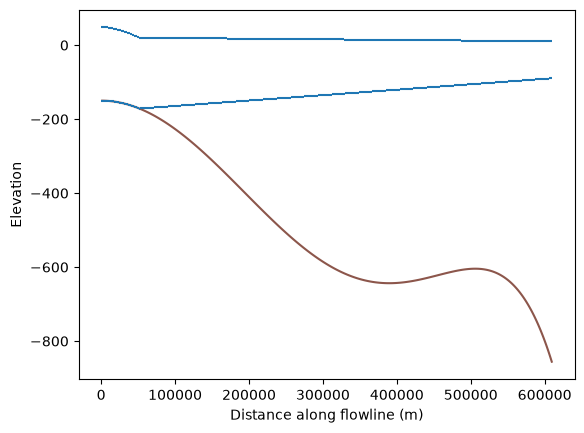

In [5]:
fig, axes = plt.subplots()
fd.plot(b, axes=axes, edgecolor="tab:brown")
fd.plot(s0, axes=axes, edgecolor="tab:blue")
fd.plot(z_b, axes=axes, edgecolor="tab:blue")
axes.set_xlabel('Distance along flowline (m)')
axes.set_ylabel('Elevation')
plt.show()

In [6]:
δu = fd.Constant(90.0)
expr = fd.as_vector([δu * x / Lx])  # 1-component vector
u_0 = fd.Function(V).interpolate(expr)

In [7]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** n)
u_c = Constant(K * τ_c ** m)

In [8]:
print(f"Strain rate: {1000 * float(ε_c):0.3f} m / yr / km")
print(f"Speed:       {float(u_c):0.3f} m / yr")
print(f"at stress of {1000 * float(τ_c):0.3f} kPa")

Strain rate: 0.020 m / yr / km
Speed:       1.000 m / yr
at stress of 10.000 kPa


In [9]:
"""
Initialization of function spaces and mass/momentum balance
"""

Z = V * Σ * V
z = fd.Function(Z)
z.sub(0).assign(u_0);

inflow_ids = (1,)
terminus_ids = (2,)

#s = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s = max_value(b + h, (1 - ρ_I / ρ_W) * h)

u, M, τ = fd.split(z)

# Mutable State (partially derived from z?)?
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

parameters_1 = {
    "flow_law_coefficient": ε_c / τ_c,
    "flow_law_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
    "sliding_exponent": 1,
}

parameters_3 = {
    "flow_law_coefficient": ε_c / τ_c ** n,
    "flow_law_exponent": n,
    "sliding_coefficient": u_c / τ_c ** m,
    "sliding_exponent": m,
}

α = Constant(1e-3)
F_flow_law_1 = flow_law(**fields, **parameters_1)
F_flow_law_3 = flow_law(**fields, **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**fields, **parameters_1)
F_sliding_law_3 = friction_law(**fields, **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F = F_flow_law + F_sliding_law + F_balance + F_terminus

inflow_bc = fd.DirichletBC(Z.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

fparams = {"quadrature_degree": 8}
pparams = {"bcs": bcs, "form_compiler_parameters": fparams}
problem = fd.NonlinearVariationalProblem(F, z, **pparams)

logfile = ":mismipp-dual.log"
sparams = {
    "solver_parameters": {
        "snes_max_it": 200,
        "snes_linesearch_type": "nleqerr",
        "snes_monitor": logfile,
        "pc_factor_mat_solver_type": "umfpack",
    }
}
solver = fd.NonlinearVariationalSolver(problem, **sparams)
solver.solve()
u, M, τ = z.subfunctions

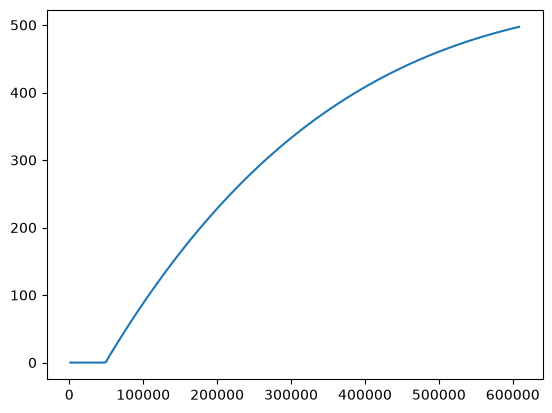

In [10]:
fig, axes = plt.subplots()
fd.plot(fd.Function(S).interpolate(u[0]), axes=axes);

In [11]:
W = V * Σ * V * Q

w = fd.Function(W)
w.sub(0).assign(z.sub(0))
w.sub(1).assign(z.sub(1))
w.sub(2).assign(z.sub(2))
w.sub(3).assign(h);

In [12]:
inflow_bc = fd.DirichletBC(W.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

u, M, τ, h = fd.split(w)
v, N, σ, η = fd.TestFunctions(W)

s = lag(max_value(b + h, (1 - ρ_I / ρ_W) * h))
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

h_min = Constant(1e-3)
regularized = {"thickness": max_value(h_min, h)}

H = Constant(500.0)

F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F_momentum = F_flow_law + F_sliding_law + F_balance + F_terminus

In [13]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**(fields | regularized))
F_terminus = terminus(**(fields | regularized), terminus_ids=terminus_ids)

F_momentum_regularized = F_flow_law + F_sliding_law + F_balance + F_terminus

In [14]:
a_0 = Constant(1.0)
m_0 = Constant(1.125)
z_b = s - h
heaviside = lambda z: 1 / (1 + fd.exp(-z))
#a_expr = a_0 - m_0 * heaviside(-z_b) * heaviside(z_b - b)
a_expr = a_0 - m_0 * heaviside(z_b - b)

In [15]:
F_mass = mass_balance(
    thickness=h, velocity=u, accumulation=lag(a_expr), thickness_in=h_0
)
F = F_momentum + F_mass
Fp = F_momentum_regularized + F_mass

In [16]:
"""
Main driver:
"""

method = irksome.BackwardEuler()
t = Constant(0.0)
timestep = 0.2
dt = Constant(timestep)

fparams = {"quadrature_degree": 8}
sparams = {
    "snes_monitor": ":mismip-dual-ts.log",
    "snes_type": "vinewtonrsls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_max_it": 200,
    "snes_max_it": 1000,
    "snes_atol": 2e-8,
    "snes_rtol": 1e-4,
    "pc_factor_mat_solver_type": "mumps",
}
lower = fd.Function(W)
upper = fd.Function(W)
lower.assign(-np.inf)
lower.sub(3).assign(0.0)
upper.assign(+np.inf)

params = {
    "bcs": bcs,
    "form_compiler_parameters": fparams,
    "solver_parameters": sparams,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": ("stage", lower, upper)
}

solver = irksome.TimeStepper(F, method, t, dt, w, **params, Jp=Fp)

In [17]:
ws = [w.copy(deepcopy=True)]
final_time = 3000.0
num_steps = int(final_time / timestep)

for step in trange(num_steps):
    solver.advance()
    ws.append(w.copy(deepcopy=True))

  0%|          | 0/15000 [00:00<?, ?it/s]

In [18]:
u, M, τ, h = w.subfunctions

In [19]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h))
z_b = fd.Function(Q).interpolate(s - h)

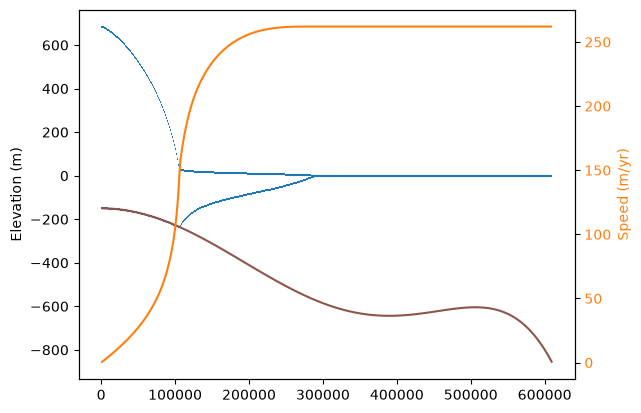

In [20]:
fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

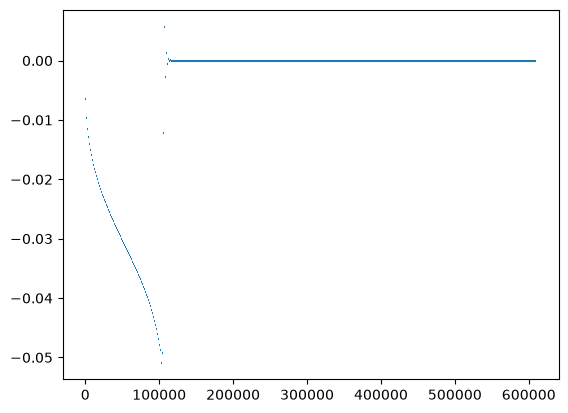

In [21]:
τ_b = fd.Function(Q).project(τ[0])
fig, ax = plt.subplots()
fd.plot(τ_b, axes=ax);

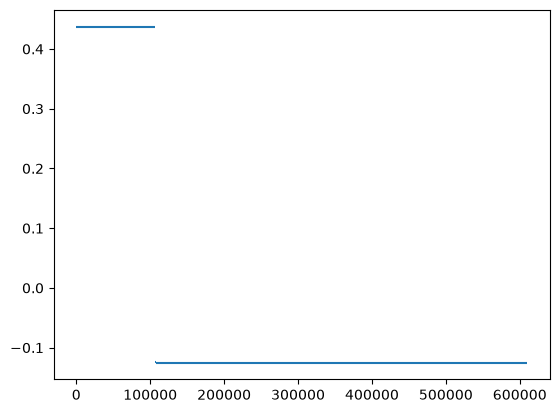

In [22]:
fig, ax = plt.subplots()
a_expr = a_0 - m_0 * heaviside(z_b - b)
a = fd.Function(Q).project(a_expr)
fd.plot(a, axes=ax);

In [23]:
# # create a function on our mesh that will assign each element in our mesh a number
# V_dg = FunctionSpace(mesh, "DG", 0)
# cell_marker = Function(V_dg)

# marker_array = cell_marker.dat.data

# for i in range(415):
#     marker_array[target_cell_index] = target_

In [24]:
def create_submesh(k):
    # create a function on our mesh that will assign each element in our mesh a number
    V_dg = fd.FunctionSpace(mesh, "DG", 0)
    cell_marker = fd.Function(V_dg)

    marker_array = cell_marker.dat.data
    marker_array[k] = 1
    relabeled_mesh = fd.RelabeledMesh(mesh, [cell_marker], [k])
    return fd.mesh.Submesh(relabeled_mesh, 1, k) 

In [25]:
element_length = 610_000/450

In [26]:
# def end_of_glacier(f):
#     """
#     This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
#     """
#     f_values = f.dat.data_ro
#     zero_nodes = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]

#     # if the this is the case then the terminus lies outside of our domain
#     if len(zero_nodes) == 0:
#         return 'empty'

#     # this gives us the first node of our mesh at which the thickness is zero
#     initial_guess = zero_nodes[0]

#     # we create a submesh with just the element that contains our terminus
#     submesh = create_submesh(initial_guess-1) 

#     print(initial_guess)
#     print(submesh.coordinates.dat.data_ro)

#     points = np.arange((initial_guess-1)*element_length, (initial_guess)*element_length)[:, None]
#     # print(points)
#     vom = fd.VertexOnlyMesh(submesh, points)
#     P = fd.FunctionSpace(vom, "DG", 0)

#     # "DG", "interval", 0
#     V_sub = fd.FunctionSpace(submesh, "DG", 0)
#     f_submesh = fd.Function(V_sub).project(f)

#     f_at_points = fd.assemble(fd.interpolate(f_submesh, P)) 
#     f_values = f_at_points.dat.data_ro

#     print(f_values)

#     zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
#     print(zeros)
#     return int(initial_guess*element_length + zeros[0])

## Introducing Stochastic Calving 

### Determining the Terminus

For calving events we need to know where the terminus is to be able to determine where the new terminus should be after the calving has occurred. 
In most cases, and assumed in my approach so far, the terminus is just the first point where the thickness function is zero. 
1. The first function I have defined finds this spot by creating a vertex only mesh for each integer value along the flow line (so for every meter) and then using np.where() to find the first value where it is zero. This is numerically quite expensive. 
A bit of a speed-up is achieved by making the spacing of the mesh larger, though for this to work one needs to multiply the result by the spacing that was used (since np.where returns the value's spot in the list of not its coordinates).
2. Another option is to access the values of the function at the nodes of the mesh using '.dat.data_ro'. This is an attribute of the function and is therefore quite fast.
The problem with this approach is that there are only 450 intervals, so the step sizes are about 1335 which means the actual terminus position can be up to 1.3 km further to the left.
3. The next option would be to combine these two approaches. This would mean first finding the interval in which the terminus lies and then using creating a finer vertex only mesh on that interval to find the exact position.

In [27]:
def end_of_glacier_slow(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, 1)[:, None] # list of lists (requirement for the vertex only mesh)
    vom = fd.VertexOnlyMesh(f_mesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    # if f_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
    #     return 'empty'
    zeros = np.where(f_values==0)[0]

    return zeros[0]*1 # this gives us the first point at which the thickness is zero

In [28]:
def logistic_function(y, new_term, k=10):
    """A variation on the logistic function that is 1 at -∞ and 0 at ∞ and continuously moves between the two centered at new_term. 
    The steepness of the transition is give by k."""
    # x = ufl.SpatialCoordinate(Q)
    return 1-1/(1+ufl.exp(-k*(y-new_term)))

### Solver #2: exponential rate calving approach

This solver implements rate based calving. We assume that we have exponentially distributed calving events.
The size of the calving events is normally distributed.

In [29]:
"""Calving with exponentially distributed occurrance and size"""

mean = 9_000
deviation = 4_000
beta = 5000
num_calv_events = 10

calving_spacing = np.random.exponential(beta, num_calv_events)
calve_time = calving_spacing.cumsum().round()
calve_size = np.random.normal(mean, deviation, num_calv_events).round()

# this next code ensures that we do 15_000 time steps (and not more)
calve_num = np.where(calve_time>= 15_000)[0]
if len(calve_num)==0:
    icebergs = calve_size
    calving_events = calve_time
else:
    icebergs = np.append(calve_size[:calve_num[0]], 0)
    calving_events = np.append(calve_time[:calve_num[0]], 15000)

print(calve_size)
print(icebergs)

print(calve_time)
print(calving_events)

[10175. 10180.  8367.  3595.  8646. -1227.  2495. 10202.  9575. 10644.]
[10175. 10180.  8367.     0.]
[ 6147. 11159. 14311. 23049. 26602. 32438. 34293. 37851. 47065. 49590.]
[ 6147. 11159. 14311. 15000.]


In [30]:
w2 = w

solver2 = irksome.TimeStepper(F, method, t, dt, w2, **params, Jp=Fp)

final_time = 3000
num_steps = int(final_time / timestep)

ws = [w2.copy(deepcopy=True)]
terminus_pos = []

step = 0
for i, e in enumerate(calving_events):
    while step < e:
        print(step)
        solver2.advance()
        step += 1
        ws.append(w2.copy(deepcopy=True))

    print(step)
    h = w2.sub(3)
    f = fd.Function(Q)
    term = end_of_glacier_slow(h)
    if term == 'empty':
        solver2.advance()
        step += 1
        ws.append(w2.copy(deepcopy=True))
    else:
        new_term = int(term - icebergs[i])
        terminus_pos += [(term, new_term)]
        print((term, new_term))
        x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
        # expr = fd.conditional(fd.le(x, new_term), h, 0.0)
        # h_at_x = h.at(x)[0]
        # expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)
        expr = h * logistic_function(x[0], new_term)
        f.interpolate(expr)
        w2.sub(3).assign(f)

        solver2.advance()
        step += 1
        ws.append(w2.copy(deepcopy=True))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

### Solver #3: position based calving approach
This solver is supposed to incorporate calving that is dependent on the position of the terminus of the glacier. 
This is numerically quite bad because for each(!) time step the terminus has to be calculated, which is numerically very expensive.
Based on the terminus position the probability that a calving event will occur is then calculated.
This means that we have a process of Bernoulli trials that are neither independent nor identically distributed (very crazy and bad).
This in turn means that the waiting times between events are not exponentially distributed (might be bad).

For the calving size I have two ideas/options:
1. Current implementation: The new terminus is determined based on the current position (approximately normally distributed behind the current position). 
This is not working not so well at the moment.
It can lead to very large calving events if the terminus is very far along the flow line (for this reason this method only works from a steady state).
Another problem with this approach is that it can technically lead to the theoretical terminus being farther in front.
In practice the implementation prevents this from happening, but it still skews the distribution 
(as in: it becomes less likely for a calving event to occur than one would assume based on the probabilities for the Bernoulli trial).
2. The calving size is independent of the terminus position. So we have a normal distribution centered around expected iceberg size.
This might actually the better approach at the moment.

In [31]:
def calving_prob(term_pos):
    """takes the terminus position as an argument and returns whether or not a calving event occurrs at this time step"""
    p = sp.stats.norm(400_000, 10_000).cdf(term_pos) # for each point the probabilty of a calving event is the cdf of the normal distribution at that point
    return int(np.random.binomial(1, p, 1)[0])

NameError: name 'sp' is not defined

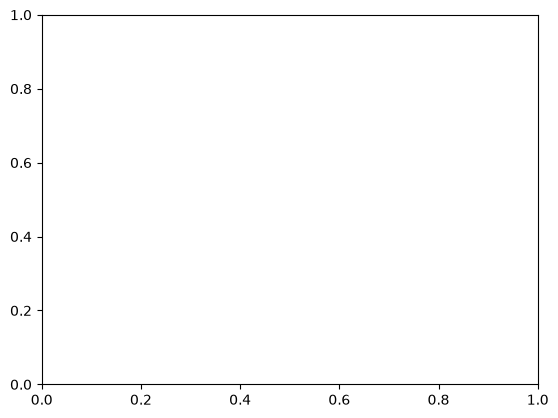

In [32]:
# this plot is there to help visualize the probability of the calving event occuring at each spot along the flow line
# at the moment there is no specific reason why I chose the cdf of the normal distribution other than that it fits the shape I want and is easily adjustable
# the connection to a probability distribution could be misleading because I could really choose any function with image [0,1]
fig, ax = plt.subplots()
x = np.linspace(0,600_000, 600_000)
ax.plot(x, sp.stats.norm(300_000, 10_000).cdf(x));

In [ ]:
# problem: leads to large jumps toward the middle
def new_terminus(term_pos):
    """this function determines the new terminus position based on the current position"""
    return int(np.random.normal((term_pos+500_000)//2, (term_pos+200_000)//16, 1)[0])

In [ ]:
def calve_size():
    return int(np.random.normal(20_000, 10_000))

In [ ]:
w3 = w

# params_3 = params.pop("stage_type")
# scheme = irksome.DiscontinuousGalerkinScheme(1)
# solver3 = irksome.discontinuous_galerkin_stepper.DiscontinuousGalerkinTimeStepper(F, scheme, t, dt, w3, **params, Jp=Fp)

solver3 = irksome.TimeStepper(F, method, t, dt, w3, **params, Jp=Fp)

ws = [w3.copy(deepcopy=True)]
calve_term_change_list= []
term_position = []


for n in trange(num_steps):
    h = w3.sub(3) # thickness
    f = fd.Function(Q)
    # g = fd.Function(Q)
    term = end_of_glacier2(h) # determine terminus
    term_position += [term]
    if term == 'empty': # if the terminus is outside the domain, no calving
        solver3.advance()
        ws.append(w3.copy(deepcopy=True))
    else:
        p = calving_prob(term)
        if p == 0: # no calving
            solver3.advance()
            ws.append(w3.copy(deepcopy=True))
        # # Position based calving size
        # else:
        #     new_term = new_terminus(term) # determine new terminus
        #     calve_term_change_list += [(term, new_term)]
        #     # print((term, new_term))

        #     x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
        #     # this imposes the new terminus by defining a new function that is 0 up flow of the new terminus (also does not allow for "forward calving")
        #     expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)  
        #     f.interpolate(expr)
        #     w3.sub(3).assign(f)

        #     solver3.advance()
        #     ws.append(w3.copy(deepcopy=True))
        # Rate based calving size
        else:
            new_term = term-calve_size() # determine new terminus
            calve_term_change_list += [(term, new_term)]
            # print((term, new_term))

            x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
            # this imposes the new terminus by defining a new function that is 0 up flow of the new terminus (also does not allow for "forward calving")
            # expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)
            # expr_1 = logistic_function(x, new_term)
            # g.interpolate(expr_1)
            expr = h * (1 - 1/(1+ufl.exp(-10*(x[0]-new_term))))
            f.interpolate(expr)
            w3.sub(3).assign(f)

            solver3.advance()
            ws.append(w3.copy(deepcopy=True))

### Analyzing and Plotting the Results

In [ ]:
print(terminus_pos)

[(np.int64(479867), 465100)]


In [ ]:
print(calve_term_change_list)

print(term_position)

NameError: name 'calve_term_change_list' is not defined

In [ ]:
def terminus_development(term_list):
    """This function takes a list of values and then creates an x-axis that enumerates the points. In this context this is useful for plottting a 
    quantity that we are trackin over time (so for each time step)."""
    n = len(term_list)
    x_list = np.arange(n)
    fig, ax = plt.subplots()
    # ax.set_ylim(100_000, 600_000)
    return ax.plot(x_list, term_list)

In [ ]:
# this plot shows the velocity at approximatley the terminus of the glacier
# it seems that the velocity changes quite a bit and quite rapidly (I don't understand the physics of this)

terminus_velocities = []
for w in ws:
    u = w.sub(0)
    u_at_points = u.dat.data_ro
    terminus_velocities += [int(u_at_points[-1])]

print(terminus_velocities)

terminus_development(terminus_velocities)

In [ ]:
u, M, τ, h = w.subfunctions # w is a field consisting of velocity, membrane stress, basal stress, thickness

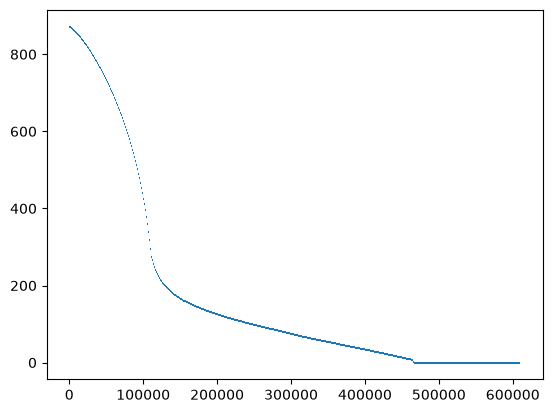

In [ ]:
# a plot of the thickness function
fig, axes = plt.subplots()
fd.plot(h, axes=axes);

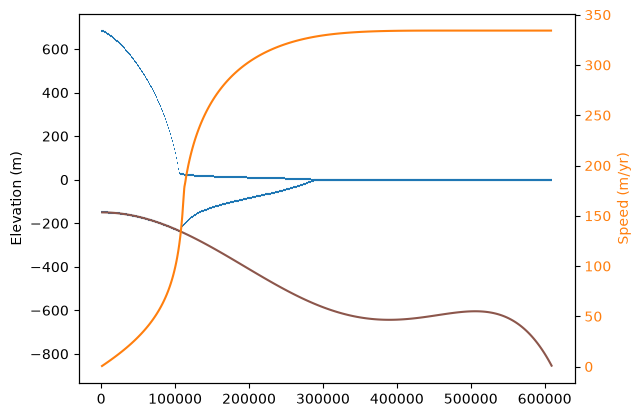

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);